In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18


# ── Dataset ───────────────────────────────────────────────────────────────────

# Run this once to confirm the true keypoints
def inspect_kp_ranges(root, n=50):
    xs, ys = [], []
    for file in sorted(os.listdir(root))[:n]:
        if not file.endswith("_pose.npz"):
            continue
        kp = np.load(os.path.join(root, file))["kp"][0]
        xs.append(kp[:, 0].max())
        ys.append(kp[:, 1].max())
    print(f"kp x max over {n} files: {max(xs):.1f}")
    print(f"kp y max over {n} files: {max(ys):.1f}")

# MMVR image-plane labels use the 640 x 480 image size from the dataset README.
# Uncomment to re-confirm: inspect_kp_ranges("./dataset")

KP_X_SRC = 640   # actual camera frame width your keypoints are in
KP_Y_SRC = 480   # actual camera frame height

HM_H = 256       # radar heatmap height
HM_W = 128       # radar heatmap width

VIS_THRESH = 0.3  # visibility is a float [0,1]; ignore low-confidence keypoints


class MMVRDataset(Dataset):
    def __init__(self, root, max_samples=200):
        self.samples = []
        for file in sorted(os.listdir(root)):
            if file.endswith("_radar.npz"):
                idx = file.replace("_radar.npz", "")
                self.samples.append(os.path.join(root, idx))
        self.samples = self.samples[:max_samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        base = self.samples[i]
        radar = np.load(base + "_radar.npz")

        hori = radar["hm_hori"].astype(np.float32)   # (256, 128) — always clean
        vert = radar["hm_vert"].astype(np.float32)   # (256, 128) — NaN in this section

        # FIX: handle NaNs before any further processing to prevent them from propagating through the pipeline
        hori = np.nan_to_num(hori, nan=0.0, posinf=0.0, neginf=0.0)
        vert = np.nan_to_num(vert, nan=0.0, posinf=0.0, neginf=0.0)

        # FIX: clip outliers to prevent them from dominating the normalization step
        hori = np.clip(hori, 0.0, np.percentile(hori, 99))
        vert = np.clip(vert, 0.0, np.percentile(vert, 99))

        hori = hori / (np.max(hori) + 1e-6)
        vert = vert / (np.max(vert) + 1e-6)

        radar_input = np.stack([hori, vert], axis=0)          # (2, H, W)
        radar_input = radar_input / (np.max(radar_input) + 1e-6)  # re-normalize after stacking

        # CHecking for NaNs after processing steps
        if np.isnan(radar_input).any():
            raise ValueError(f"NaN detected in radar input for sample {i}")

        pose = np.load(base + "_pose.npz")              # (2, H, W)
        kp   = pose["kp"][0].copy().astype(np.float32)  # (17, 3): x, y, visibility

        # Map keypoints from source image space to radar heatmap space, then clamp to valid pixel bounds
        kp[:, 0] = kp[:, 0] * HM_W / KP_X_SRC  # x -> [0, 128]
        kp[:, 1] = kp[:, 1] * HM_H / KP_Y_SRC  # y -> [0, 256]
        kp[:, 0] = np.clip(kp[:, 0], 0, HM_W - 1)
        kp[:, 1] = np.clip(kp[:, 1], 0, HM_H - 1)

        return (
            torch.tensor(radar_input, dtype=torch.float32),
            torch.tensor(kp,          dtype=torch.float32),
        )

# ── GT heatmap generation ─────────────────────────────────────────────────────

def make_heatmaps(kp_np, H=HM_H, W=HM_W, sigma=4):
    """kp_np: (17,3)  x in [0,W), y in [0,H), vis in [0,1]"""
    maps = np.zeros((17, H, W), dtype=np.float32)
    xx, yy = np.meshgrid(np.arange(W), np.arange(H))
    for j in range(17):
        x, y, v = kp_np[j]
        if v > VIS_THRESH:
            maps[j] = np.exp(-((xx - x)**2 + (yy - y)**2) / (2 * sigma**2))
    return torch.tensor(maps, dtype=torch.float32)


# ── Model ─────────────────────────────────────────────────────────────────────

class SoftArgmax2D(nn.Module):
    def forward(self, x):
        B, C, H, W = x.shape

        # Subtract spatial max before softmax to prevent exp() overflow
        x = x - x.amax(dim=(2,3), keepdim=True)
        x_flat = F.softmax(x.view(B, C, -1), dim=-1)
        idx    = torch.arange(H * W, device=x.device).float()
        xs     = idx % W
        ys     = torch.div(idx, W, rounding_mode='floor')

        return torch.stack([
            torch.sum(x_flat * xs, dim=-1),
            torch.sum(x_flat * ys, dim=-1),
        ], dim=-1)   # (B, C, 2)


class AttentionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Conv2d(channels, channels, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.attn(x)


class PoseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(2,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
        )
        self.res = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),
        )
        self.attn = AttentionBlock(64)
        self.dec = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        )
        self.out         = nn.Conv2d(32, 17, 1)
        self.soft_argmax = SoftArgmax2D()
        self.coord_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 17 * 2),
        )

    def forward(self, x):
        x        = self.enc(x)
        x        = F.relu(x + self.res(x))
        x        = self.attn(x)
        coord_features = x
        x        = self.dec(x)
        heatmaps = self.out(x)
        soft_coords = self.soft_argmax(heatmaps)
        coord_delta = self.coord_head(coord_features).view(-1, 17, 2)
        coords   = soft_coords + coord_delta
        return heatmaps, coords


class ResNetPose(nn.Module):
    def __init__(self):
        super().__init__()
        self.net         = resnet18(weights=None)
        self.net.conv1   = nn.Conv2d(2, 64, 7, stride=2, padding=3, bias=False)
        self.net.fc      = nn.Linear(512, 34)

    def forward(self, x):
        return self.net(x).view(-1, 17, 2)


# ── Training ──────────────────────────────────────────────────────────────────

dataset = MMVRDataset("./dataset", max_samples=200)

# Split the data into sections that can be used for each step of the process
# This should prevent our model from appearing to perform really well because of using the training data to test on
n_total = len(dataset)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

generator = torch.Generator().manual_seed(486)

train_ds, val_ds, test_ds = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=generator
)

loader      = DataLoader(train_ds, batch_size=8, shuffle=True, drop_last=True)
val_loader  = DataLoader(val_ds, batch_size=8, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

print(f"Split sizes: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Sanity check before training
x0, kp0 = dataset[0]
assert not torch.isnan(x0).any(),  "Still NaN in radar input!"
assert not torch.isnan(kp0).any(), "NaN in keypoints!"
print(f"Input OK  — range [{x0.min():.3f}, {x0.max():.3f}]")
print(f"kp x      — range [{kp0[:,0].min():.1f}, {kp0[:,0].max():.1f}]  (expect ~[0,{HM_W}])")
print(f"kp y      — range [{kp0[:,1].min():.1f}, {kp0[:,1].max():.1f}]  (expect ~[0,{HM_H}])")

# ── Model optimization ──────────────────────────────────────────────────────────

model     = PoseCNN().to(device)
baseline  = ResNetPose().to(device)

RESUME_FROM_CHECKPOINT = True
if RESUME_FROM_CHECKPOINT and os.path.exists("pose_cnn_mmvr_fixed.pth"):
    state = torch.load("pose_cnn_mmvr_fixed.pth", map_location=device)
    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f"Loaded CNN checkpoint. missing={missing}, unexpected={unexpected}")
if RESUME_FROM_CHECKPOINT and os.path.exists("resnet18_pose_mmvr_fixed.pth"):
    baseline.load_state_dict(torch.load("resnet18_pose_mmvr_fixed.pth", map_location=device))
    print("Loaded ResNet checkpoint.")

opt       = torch.optim.Adam(model.parameters(),    lr=1e-4)

# Added an optimizer for the baseline model so it actually learns
opt_baseline = torch.optim.Adam(baseline.parameters(), lr=1e-4)

# FIX: the ResNet baseline should optimize MSE on the raw keypoint coords, not heatmap.
mse_none = nn.MSELoss(reduction='none')


def quick_cnn_pck(eval_loader):
    model.eval()
    scores = []
    with torch.no_grad():
        for x, kp in eval_loader:
            x = x.to(device)
            _, pred = model(x)
            pred_np = pred.cpu().numpy()
            kp_np = kp.numpy()
            for i in range(kp_np.shape[0]):
                mask = kp_np[i, :, 2] > VIS_THRESH
                if mask.any():
                    dist = np.linalg.norm(kp_np[i, mask, :2] - pred_np[i, mask], axis=1)
                    scores.append(np.mean(dist < 0.05 * HM_H))
    model.train()
    return float(np.nanmean(scores)) if scores else 0.0


# ── Training Loop ──────────────────────────────────────────────────────────────

MAX_EPOCHS = 10000
MIN_EPOCHS = 50
TARGET_PCK = 0.90
EVAL_EVERY = 10
best_val_pck = -1.0
best_epoch = -1

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    baseline.train()

    total_loss_cnn = 0.0
    total_loss_res = 0.0
    n_ok = 0

    for x, kp in loader:
        x  = x.to(device)
        kp = kp.to(device)

        gt_maps = torch.stack(
            [make_heatmaps(k.cpu().numpy()) for k in kp]
        ).to(device)

        # Actually grab the predicted coordinates from the CNN to evaluate coordinate loss
        pred_maps, pred_coords = model(x)
        pred_resnet = baseline(x)
        
        weight = (gt_maps > 0.5).float() * 49 + 1  # 50× weight on visible keypoints, 1× on background

        # FIX: divide by sum of weights, not pixel count, so the joint-center
        # error actually drives the reported loss.
        
        # Replaced the old single loss with the dual-loss system for the CNN
        # and added the MSE loss calculation for the ResNet baseline as requested in old comments.
        heatmap_loss = (mse_none(pred_maps, gt_maps) * weight).sum() / weight.sum()
        
        target_xy = kp[:, :, :2]
        visible = (kp[:, :, 2] > VIS_THRESH).float().unsqueeze(-1)
        coord_scale = torch.tensor([HM_W, HM_H], device=device).view(1, 1, 2)
        
        coord_loss = (((pred_coords - target_xy) / coord_scale) ** 2 * visible).sum() / (visible.sum() * 2 + 1e-6)
        
        # Combine losses: prioritize exact coordinates over blurry heatmaps
        cnn_loss = heatmap_loss + 10.0 * coord_loss
        
        # Calculate ResNet Baseline loss (MSE on raw coordinates)
        resnet_loss = (((pred_resnet - target_xy) / coord_scale) ** 2 * visible).sum() / (visible.sum() * 2 + 1e-6)

        if torch.isnan(cnn_loss) or torch.isnan(resnet_loss):
            print(f"  [epoch {epoch}] NaN loss — skipping batch")
            continue

        # Train CNN
        opt.zero_grad()
        cnn_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()

        # Train ResNet Baseline
        opt_baseline.zero_grad()
        resnet_loss.backward()
        torch.nn.utils.clip_grad_norm_(baseline.parameters(), max_norm=1.0)
        opt_baseline.step()

        total_loss_cnn += cnn_loss.item()
        total_loss_res += resnet_loss.item()
        
        n_ok += 1

    # FIX: print once per EPOCH (was inside the batch loop, printing every iteration).

    print(
        f"Epoch {epoch:02d}  "
        f"cnn_loss={total_loss_cnn / max(n_ok,1):.4f}  " 
        f"resnet_loss={total_loss_res / max(n_ok,1):.4f}  " 
        f"({n_ok}/{len(loader)} batches OK)"
    )

    if epoch % EVAL_EVERY == 0:
        val_pck = quick_cnn_pck(val_loader)
        print(f"Validation CNN accuracy/PCK@5%: {val_pck:.3f}")
        if val_pck > best_val_pck:
            best_val_pck = val_pck
            best_epoch = epoch
            torch.save(model.state_dict(), "pose_cnn_mmvr_fixed.pth")
            # ResNet is not part of the early-stop target; save it once after training.
            print(f"Saved best checkpoints at epoch {epoch} (val PCK={val_pck:.3f})")
        if epoch >= MIN_EPOCHS and val_pck >= TARGET_PCK:
            print(f"Target reached: validation CNN accuracy/PCK@5%={val_pck:.3f}; stopping.")
            break

if best_epoch >= 0:
    model.load_state_dict(torch.load("pose_cnn_mmvr_fixed.pth", map_location=device))
    # Keep the in-memory ResNet baseline; only the CNN is restored to its best epoch.
    print(f"Loaded best checkpoints from epoch {best_epoch} (val PCK={best_val_pck:.3f})")

# ── Metrics ───────────────────────────────────────────────────────────────────

def valid(gt, pred):
    """Return only the visible-keypoint rows AND the boolean mask used —
       so callers can index a per-joint confidence vector with the same mask.
    """
    mask = gt[:, 2] > VIS_THRESH
    return gt[mask, :2], pred[mask], mask


def mae(gt, pred):
    g, p, _ = valid(gt, pred)
    if len(g) == 0:
        return np.nan
    return np.mean(np.linalg.norm(g - p, axis=1))


def pck(gt, pred, frac=0.05):
    # FIX: must call valid() BEFORE referencing g (was a NameError).
    g, p, _ = valid(gt, pred)
    if len(g) == 0:
        return np.nan
    return np.mean(np.linalg.norm(g - p, axis=1) < frac * HM_H)


def oks(gt, pred):
    g, p, _ = valid(gt, pred)
    if len(g) == 0:
        return np.nan
    d_sq = np.sum((g - p)**2, axis=1)
    return np.mean(np.exp(-d_sq / (2 * (HM_H * HM_W) * 0.05**2)))


def precision_recall_f1(gt, pred, conf=None, conf_thresh=0.1, thresh_px=5.0):
    """Per-joint confidence defines abstention.
       TP : confident AND localized within thresh_px
       FP : confident AND beyond  thresh_px
       FN : visible GT but model abstained (low confidence) — independent of d
       If conf is None we treat every prediction as confident — which means
       Precision == Recall == PCK by construction (a property of a model
       with no abstention head, e.g. the ResNet baseline).
    """
    g, p, mask = valid(gt, pred)
    if len(g) == 0:
        return np.nan, np.nan, np.nan

    # FIX: was `if c is None` (c was undefined) and missed the else-branch
    # that masks `conf` down to the visible-only joints.
    if conf is None:
        c = np.ones(len(g), dtype=np.float32)
    else:
        c = np.asarray(conf)[mask]

    d  = np.linalg.norm(g - p, axis=1)
    pp = c > conf_thresh

    # FIX: FN = "visible GT but model abstained" — does NOT depend on d.
    # The previous version restricted FN to "would-have-been-TP misses",
    # which under-counts misses and inflates recall.
    tp = int(np.sum(pp & (d <  thresh_px)))
    fp = int(np.sum(pp & (d >= thresh_px)))
    fn = int(np.sum(~pp))

    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)
    return precision, recall, f1


# ── Evaluation ────────────────────────────────────────────────────────────────

def apply_robustness(x, scenario="clean"):
    if scenario in ["clean", "darkness"]:
        # Darkness affects RGB cameras; this project uses radar-only input.
        return x
    x = x.clone()
    if scenario == "occlusion":
        _, _, H, W = x.shape
        x[:, :, 3*H//7:4*H//7, 3*W//7:4*W//7] = 0.0
        return x
    if scenario == "clutter":
        return torch.clamp(x + torch.randn_like(x) * 0.05, 0.0, 1.0)
    raise ValueError(f"Unknown robustness scenario: {scenario}")


def evaluate_loader(loader, split_name, scenario="clean"):
    model.eval()
    baseline.eval()

    # Store per-sample metrics for each model, then average them at the end.
    results = {
        "CNN (ours)": {
            "mae": [], "pck": [], "oks": [], "precision": [], "recall": [], "f1": []
        },
        "ResNet-18 baseline": {
            "mae": [], "pck": [], "oks": [], "precision": [], "recall": [], "f1": []
        }
    }

    with torch.no_grad():
        for x, kp in loader:
            x = x.to(device)
            x_eval = apply_robustness(x, scenario)

            heat, pred_cnn = model(x_eval)
            pred_resnet = baseline(x_eval)

            pred_cnn_np = pred_cnn.cpu().numpy()
            pred_resnet_np = pred_resnet.cpu().numpy()

            # Heatmap peak is used as the CNN's confidence score per keypoint.
            conf_cnn_np = heat.amax(dim=(2, 3)).cpu().numpy()
            kp_np = kp.numpy()

            for i in range(kp_np.shape[0]):
                for name, pred, conf in [
                    ("CNN (ours)", pred_cnn_np[i], conf_cnn_np[i]),
                    ("ResNet-18 baseline", pred_resnet_np[i], None),
                ]:
                    results[name]["mae"].append(mae(kp_np[i], pred))
                    results[name]["pck"].append(pck(kp_np[i], pred))
                    results[name]["oks"].append(oks(kp_np[i], pred))

                    # ResNet has no confidence output, so precision/recall use conf=None.
                    p, r, f = precision_recall_f1(kp_np[i], pred, conf=conf)
                    results[name]["precision"].append(p)
                    results[name]["recall"].append(r)
                    results[name]["f1"].append(f)

    print(f"\n=== {split_name} Results ({scenario}) ===")

    for name, metrics in results.items():
        print(f"\n{name}")

        # nanmean avoids one invalid sample breaking the final average.
        print(f"  Accuracy  : {np.nanmean(metrics['pck']):.3f} (PCK@5%)")
        print(f"  MAE       : {np.nanmean(metrics['mae']):.3f} px")
        print(f"  PCK@5%    : {np.nanmean(metrics['pck']):.3f}")
        print(f"  OKS       : {np.nanmean(metrics['oks']):.3f}")
        print(f"  Precision : {np.nanmean(metrics['precision']):.3f}")
        print(f"  Recall    : {np.nanmean(metrics['recall']):.3f}")
        print(f"  F1        : {np.nanmean(metrics['f1']):.3f}")


evaluate_loader(val_loader, "Validation")
evaluate_loader(test_loader, "Test")
evaluate_loader(test_loader, "Test Robustness", scenario="darkness")
evaluate_loader(test_loader, "Test Robustness", scenario="occlusion")
evaluate_loader(test_loader, "Test Robustness", scenario="clutter")

torch.save(model.state_dict(), "pose_cnn_mmvr_fixed.pth")
try:
    torch.save(baseline.state_dict(), "resnet18_pose_mmvr_fixed.pth")
except RuntimeError as e:
    print(f"Could not overwrite ResNet checkpoint: {e}")
    torch.save(baseline.state_dict(), "resnet18_pose_mmvr_fixed_new.pth")
    print("Saved ResNet checkpoint to resnet18_pose_mmvr_fixed_new.pth instead.")

print("Saved checkpoints.")

Split sizes: train=140, val=30, test=30
Using device: cuda
Input OK  — range [0.000, 1.000]
kp x      — range [10.5, 46.3]  (expect ~[0,128])
kp y      — range [3.1, 252.9]  (expect ~[0,256])


C:\Users\rover\AppData\Local\Temp\ipykernel_15508\4129171215.py:223: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load("pose_cnn_mmvr_fixed.pth", map_location

Loaded CNN checkpoint. missing=[], unexpected=[]
Loaded ResNet checkpoint.
Epoch 01  cnn_loss=0.0249  resnet_loss=0.0000  (17/17 batches OK)
Epoch 02  cnn_loss=0.0211  resnet_loss=0.0000  (17/17 batches OK)
Epoch 03  cnn_loss=0.0194  resnet_loss=0.0000  (17/17 batches OK)
Epoch 04  cnn_loss=0.0193  resnet_loss=0.0000  (17/17 batches OK)
Epoch 05  cnn_loss=0.0202  resnet_loss=0.0000  (17/17 batches OK)
Epoch 06  cnn_loss=0.0178  resnet_loss=0.0000  (17/17 batches OK)
Epoch 07  cnn_loss=0.0184  resnet_loss=0.0000  (17/17 batches OK)
Epoch 08  cnn_loss=0.0200  resnet_loss=0.0000  (17/17 batches OK)
Epoch 09  cnn_loss=0.0184  resnet_loss=0.0000  (17/17 batches OK)
Epoch 10  cnn_loss=0.0210  resnet_loss=0.0000  (17/17 batches OK)
Validation CNN accuracy/PCK@5%: 0.853
Saved best checkpoints at epoch 10 (val PCK=0.853)
Epoch 11  cnn_loss=0.0234  resnet_loss=0.0000  (17/17 batches OK)
Epoch 12  cnn_loss=0.0181  resnet_loss=0.0000  (17/17 batches OK)
Epoch 13  cnn_loss=0.0181  resnet_loss=0.000

C:\Users\rover\AppData\Local\Temp\ipykernel_15508\4129171215.py:351: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("pose_cnn_mmvr_fixed.pth"

Loaded best checkpoints from epoch 40 (val PCK=0.916)

=== Validation Results (clean) ===

CNN (ours)
  Accuracy  : 0.916 (PCK@5%)
  MAE       : 6.647 px
  PCK@5%    : 0.916
  OKS       : 0.753
  Precision : 0.446
  Recall    : 0.900
  F1        : 0.566

ResNet-18 baseline
  Accuracy  : 0.993 (PCK@5%)
  MAE       : 1.781 px
  PCK@5%    : 0.993
  OKS       : 0.968
  Precision : 0.950
  Recall    : 1.000
  F1        : 0.967

=== Test Results (clean) ===

CNN (ours)
  Accuracy  : 0.835 (PCK@5%)
  MAE       : 7.910 px
  PCK@5%    : 0.835
  OKS       : 0.705
  Precision : 0.423
  Recall    : 0.900
  F1        : 0.545

ResNet-18 baseline
  Accuracy  : 0.989 (PCK@5%)
  MAE       : 2.339 px
  PCK@5%    : 0.989
  OKS       : 0.948
  Precision : 0.931
  Recall    : 1.000
  F1        : 0.951

=== Test Robustness Results (darkness) ===

CNN (ours)
  Accuracy  : 0.835 (PCK@5%)
  MAE       : 7.910 px
  PCK@5%    : 0.835
  OKS       : 0.705
  Precision : 0.423
  Recall    : 0.900
  F1        : 0.545


Ground truth x range: 83.828125 91.328125
Ground truth y range: 102.875 179.125
CNN x range: 85.170654 91.55012
CNN y range: 96.56942 185.18924
Center would be: 64.0 128.0


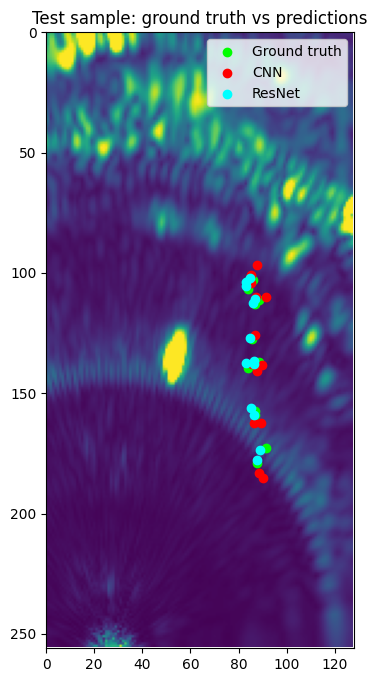

In [2]:
import matplotlib.pyplot as plt

model.eval()
baseline.eval()

x_s, kp_s = test_ds[0]
x_in = x_s.unsqueeze(0).to(device)

with torch.no_grad():
    _, pred_cnn = model(x_in)
    pred_resnet = baseline(x_in)

gt = kp_s.numpy()
cnn = pred_cnn[0].cpu().numpy()
res = pred_resnet[0].cpu().numpy()

visible = gt[:, 2] > VIS_THRESH

print("Ground truth x range:", gt[visible, 0].min(), gt[visible, 0].max())
print("Ground truth y range:", gt[visible, 1].min(), gt[visible, 1].max())
print("CNN x range:", cnn[visible, 0].min(), cnn[visible, 0].max())
print("CNN y range:", cnn[visible, 1].min(), cnn[visible, 1].max())
print("Center would be:", HM_W / 2, HM_H / 2)

plt.figure(figsize=(6, 8))
plt.imshow(x_s[0], cmap="viridis")

plt.scatter(gt[visible, 0], gt[visible, 1], c="lime", label="Ground truth")
plt.scatter(cnn[visible, 0], cnn[visible, 1], c="red", label="CNN")
plt.scatter(res[visible, 0], res[visible, 1], c="cyan", label="ResNet")

plt.xlim(0, HM_W)
plt.ylim(HM_H, 0)
plt.legend()
plt.title("Test sample: ground truth vs predictions")
plt.show()
